In [2]:
import os
from pathlib import Path
import sys


# 프로젝트 루트 경로를 찾아 src 폴더를 sys.path에 추가합니다.
def find_project_root() -> Path:
    curr = Path.cwd()
    for parent in [curr] + list(curr.parents):
        if (parent / "pyproject.toml").exists():
            return parent
    return curr

PROJECT_ROOT = find_project_root()
src_dir = str(PROJECT_ROOT / "src")
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

os.environ.setdefault("LANGSMITH_TRACING", "false")

'true'

# 1. 여러 문서 로드

In [3]:


# 경로
PDF_PATHS = [
    PROJECT_ROOT / "data/raw/pdf/saving_tips/1.pdf",
    PROJECT_ROOT / "data/raw/pdf/saving_tips/2.pdf",
    PROJECT_ROOT / "data/raw/pdf/saving_tips/3.pdf",
    PROJECT_ROOT / "data/raw/pdf/saving_tips/4.pdf",
    PROJECT_ROOT / "data/raw/pdf/saving_tips/5.pdf",
    PROJECT_ROOT / "data/raw/pdf/saving_tips/6.pdf",
    PROJECT_ROOT / "data/raw/pdf/saving_tips/7.pdf",
    PROJECT_ROOT / "data/raw/pdf/kca_report/0417_kca_split.pdf",
    PROJECT_ROOT / "data/raw/pdf/welfare/2026_hope_ladder_selected.pdf",
    PROJECT_ROOT / "data/raw/pdf/self_report/consumer_spending_report_v2.pdf",
    PROJECT_ROOT / "data/raw/txt/saving_guides.txt"
]

In [4]:
from pathlib import Path
from langchain_community.document_loaders import PDFPlumberLoader, TextLoader

all_docs = []

for path in PDF_PATHS:
    
    # 확장자 확인
    if str(path).endswith(".pdf"):
        loader = PDFPlumberLoader(str(path))
    elif str(path).endswith(".txt"):
        loader = TextLoader(str(path), encoding="utf-8")
    else:
        continue

    docs = loader.load()

    # 출처 메타데이터 추가 ⭐ 중요
    for d in docs:
        d.metadata["source"] = path.name

    all_docs.extend(docs)

print("총 문서 수:", len(all_docs))
print(all_docs[0].page_content[:500])

Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats
Could not get FontBBox from font descriptor because No

총 문서 수: 172
금융생활에 필요한 모든 정보,「파인」(fine.fss.or.kr)으로 검색하세요
“금융은 튼튼하게, 소비자는 행복하게”
보 도 참 고 자 료
보도 2017. 1. 31.(화) 조간 배포 2017. 1. 26.(목)
담당부서 금융혁신국 서정보 팀장(3145-8210) 이동춘 수석(3145-8216)
제 목 : 금융꿀팁 200선 -㉚ 사회초년생을 위한 금융꿀팁 7가지
□ 금융감독원은 국민들이 일상적인 금융거래과정에서 알아두면
유익한 실용금융정보(금융꿀팁) 200가지를 선정, 알기 쉽게 정리하여
◦ 매주 1~3가지씩 보도참고자료를 통해 안내하고
◦ 동시에 금융소비자정보 포털사이트 “파인”(fine.fss.or.kr)에도
게시하고 있음
□ 이에 따라 서른 번째 금융꿀팁으로, “사회초년생을 위한 금융꿀팁
7가지”를 별첨과 같이 안내해 드림
<별첨> 금융꿀팁 200선-㉚ 사회초년생을 위한 금융꿀팁 7가지
☞ 본 자료를 인용하여 보도할 경우에는 출처를 표기하여 주시기 바랍니다.(http://ww


# 2. 문서 split

In [5]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    separators=["\n\n"],
    chunk_size=500,
    chunk_overlap=50
)

split_docs = text_splitter.split_documents(all_docs)

print(f"청킹 후 문서 수: {len(split_docs)}")

청킹 후 문서 수: 172


# 3. 임베딩 + 벡터 DB

In [6]:
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from ragas.embeddings import LangchainEmbeddingsWrapper

base_embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

vectorstore = FAISS.from_documents(split_docs, base_embeddings)

retriever = vectorstore.as_retriever(search_kwargs={"k": 2})

ragas_embeddings = LangchainEmbeddingsWrapper(base_embeddings)

print(f"벡터 수: {vectorstore.index.ntotal}")

c:\Users\user\catcher\catcher-llm\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


벡터 수: 172


C:\Users\user\AppData\Local\Temp\ipykernel_26796\3001650575.py:11: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  ragas_embeddings = LangchainEmbeddingsWrapper(base_embeddings)


# 4. Retriever 설정

In [7]:
retriever = vectorstore.as_retriever(
    search_kwargs={"k": 2}
)

# 5. 질문 → context → 답변 생성 

In [16]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0, max_tokens=300)

q = "사회초년생이 절약을 위해 가장 먼저 해야 할 행동은?"

docs = retriever.invoke(query)

# context 모으기
context_texts = [doc.page_content[:200] for doc in docs]

# 답변 생성
answer = llm.invoke(
    f"""
질문: {q}

질문에 대한 핵심 답만 작성하세요.
다른 주제는 절대 포함하지 마세요.
문서에 있는 내용만 사용하세요.
답변은 반드시 1문장으로 작성하세요.

문서:
{context_texts}
"""
).content

print("답변:")
print(answer)

print("\n출처:")
for d in docs:
    print(d.metadata["source"])

답변:
사회초년생이 절약을 위해 가장 먼저 해야 할 행동은 계획적인 장보기를 통해 식재료를 저렴하게 구입하는 것입니다.

출처:
7.pdf
1.pdf


# 6. Ragas 평가

In [17]:
from datasets import Dataset
from ragas import evaluate
from ragas.metrics import (
    Faithfulness,
    AnswerRelevancy,
    ContextPrecision,
    ContextRecall
)

metrics = [
    Faithfulness(),
    AnswerRelevancy(),
    ContextPrecision(),
    ContextRecall()
]

questions = [
    "식비를 절약하는 방법은?",
    "불필요한 소비를 줄이는 방법은?",
    "저축을 늘리는 방법은?",
    "소비 습관을 개선하는 방법은?",
    "식비를 절약하는 방법은?"
]


answers = []
contexts = []
ground_truths = [
    "계획적인 장보기와 식재료 관리로 식비를 절약할 수 있다.",
    "필요한 것과 원하는 것을 구분하여 소비를 줄여야 한다.",
    "꾸준한 저축과 금융상품 활용이 중요하다.",
    "소비 패턴을 점검하고 불필요한 지출을 줄여야 한다.",
    "계획적인 장보기와 식재료 보존을 통해 식비를 절약할 수 있다."
]

for q in questions:
    docs = retriever.invoke(q)
    context_texts = [doc.page_content[:300] for doc in docs]

    answer = llm.invoke(
        f"""
질문: {q}

아래 문서 내용을 바탕으로 질문에 직접 답하세요.
문서에 없는 내용은 말하지 마세요.
답변은 2문장 이내로 작성하세요.

문서:
{context_texts}
"""
    ).content

    answers.append(answer)
    contexts.append(context_texts)

dataset = Dataset.from_dict({
    "question": questions,
    "answer": answers,
    "contexts": contexts,
    "ground_truth": ground_truths
})

result = evaluate(
    dataset=dataset,
    metrics=metrics,
    embeddings=ragas_embeddings
)

print(result)

C:\Users\user\AppData\Local\Temp\ipykernel_26796\3379257245.py:3: DeprecationWarning: Importing Faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import Faithfulness
  from ragas.metrics import (
C:\Users\user\AppData\Local\Temp\ipykernel_26796\3379257245.py:3: DeprecationWarning: Importing AnswerRelevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import AnswerRelevancy
  from ragas.metrics import (
C:\Users\user\AppData\Local\Temp\ipykernel_26796\3379257245.py:3: DeprecationWarning: Importing ContextPrecision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import ContextPrecision
  from ragas.metrics import (
C:\Users\user\AppData\Local\Temp\ipykernel_26796\3379

{'faithfulness': 1.0000, 'answer_relevancy': 0.8305, 'context_precision': 1.0000, 'context_recall': 0.8000}


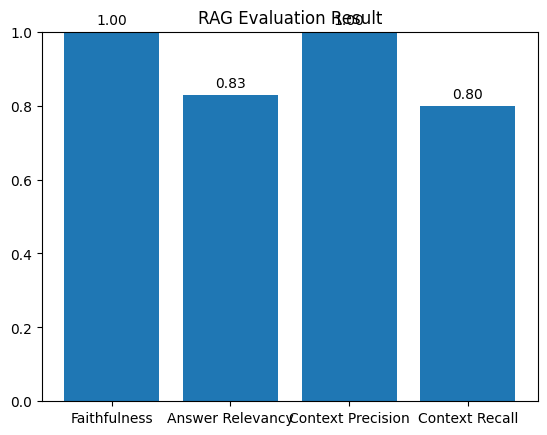

In [18]:
import matplotlib.pyplot as plt

scores = {
    'Faithfulness': 1.00,
    'Answer Relevancy': 0.83,
    'Context Precision': 1.00,
    'Context Recall': 0.80
}

plt.figure()

bars = plt.bar(scores.keys(), scores.values())

plt.ylim(0, 1)
plt.title("RAG Evaluation Result")

# 값 표시
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f"{height:.2f}",
        ha='center'
    )

plt.show()